# Tiền xử lý dữ liệu

## Import thư viện

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set(style="whitegrid", font_scale=1.1)

print("Đã import xong thư viện")

Đã import xong thư viện


## Đọc file CSV

In [4]:
train    = pd.read_csv("/content/drive/MyDrive/DataAnalysis/Project/train.csv")
features = pd.read_csv("/content/drive/MyDrive/DataAnalysis/Project/features.csv")
stores   = pd.read_csv("/content/drive/MyDrive/DataAnalysis/Project/stores.csv")

print("Train shape   :", train.shape)
print("Features shape:", features.shape)
print("Stores shape  :", stores.shape)

train.head()

Train shape   : (421570, 5)
Features shape: (8190, 12)
Stores shape  : (45, 3)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


## Gộp dữ liệu & tạo biến thời gian

In [5]:
# Gộp 3 bảng vào 1 dataframe
# Đổi Date sang kiểu datetime
for df in [train, features]:
    df["Date"] = pd.to_datetime(df["Date"])

# Merge: train + features + stores
df = train.merge(features, on=["Store", "Date"], how="left")
df = df.merge(stores, on="Store", how="left")

print("Full data shape:", df.shape)
df.head()

Full data shape: (421570, 17)


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


In [6]:
# Thêm Year, Month, Week
df["Year"]  = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"]  = df["Date"].dt.isocalendar().week.astype(int)

df[["Date","Year","Month","Week"]].head()

,Date,Year,Month,Week
0,2010-02-05,2010,2,5
1,2010-02-12,2010,2,6
2,2010-02-19,2010,2,7
3,2010-02-26,2010,2,8
4,2010-03-05,2010,3,9


## Thống kê tổng quan & missing values

In [7]:
# Xem thông tin tổng quan
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  IsHoliday_y   421570 non-null  bool          
 15  Type          421

In [8]:
# Thống kê mô tả các biến số
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Store,421570.0,22.200546,1.0,11.0,22.0,33.0,45.0,12.785297
Dept,421570.0,44.260317,1.0,18.0,37.0,74.0,99.0,30.492054
Date,421570,2011-06-18 08:30:31.963375104,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,421570.0,15981.258123,-4988.94,2079.65,7612.03,20205.8525,693099.36,22711.183519
Temperature,421570.0,60.090059,-2.06,46.68,62.09,74.28,100.14,18.447931
Fuel_Price,421570.0,3.361027,2.472,2.933,3.452,3.738,4.468,0.458515
MarkDown1,150681.0,7246.420196,0.27,2240.27,5347.45,9210.9,88646.76,8291.221345
MarkDown2,111248.0,3334.628621,-265.76,41.6,192.0,1926.94,104519.54,9475.357325
MarkDown3,137091.0,1439.421384,-29.1,5.08,24.6,103.99,141630.61,9623.07829
MarkDown4,134967.0,3383.168256,0.22,504.22,1481.31,3595.04,67474.85,6292.384031


In [9]:
# Kiểm tra missing values
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

,0
MarkDown2,310322
MarkDown4,286603
MarkDown3,284479
MarkDown1,270889
MarkDown5,270138


## Xử lý dữ liệu trùng & missing

In [10]:
# Xử lý dòng trùng lặp (nếu có)
dup_cnt = df.duplicated().sum()
print("Số dòng trùng lặp:", dup_cnt)

if dup_cnt > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Sau khi xóa trùng:", df.shape)

Số dòng trùng lặp: 0


In [14]:
# Xử lý missing cho các cột liên quan

# 1. Temperature & Fuel_Price: median theo Month
for col in ["Temperature", "Fuel_Price"]:
    if col in df.columns:
        df[col] = df.groupby("Month")[col].transform(lambda x: x.fillna(x.median()))

# 2. CPI & Unemployment: ffill + bfill theo Store
for col in ["CPI", "Unemployment"]:
    if col in df.columns:
        df[col] = df.groupby("Store")[col].transform(lambda x: x.ffill().bfill())

# 3. Fill NA nhỏ lẻ còn lại
for col in df.columns:
    if df[col].dtype != "object" and df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

df.isna().sum()[df.isna().sum() > 0]

,0


## Kiểm tra & xử lý outliers của Weekly_Sales

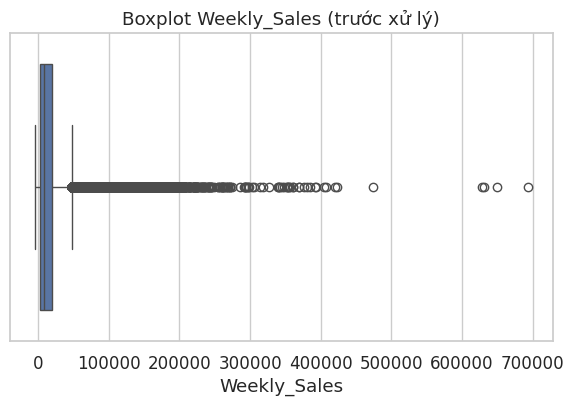

In [15]:
# Boxplot trước xử lý
plt.figure(figsize=(7,4))
sns.boxplot(x=df["Weekly_Sales"])
plt.title("Boxplot Weekly_Sales (trước xử lý)")
plt.show()

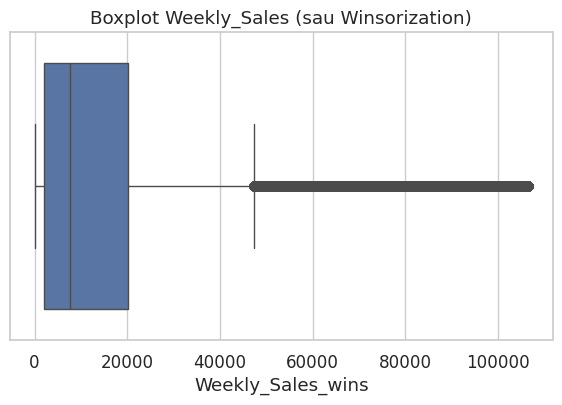

In [16]:
# Winsorization 1% hai đầu cho Weekly_Sales
df["Weekly_Sales_wins"] = stats.mstats.winsorize(
    df["Weekly_Sales"], limits=[0.01, 0.01]
)

plt.figure(figsize=(7,4))
sns.boxplot(x=df["Weekly_Sales_wins"])
plt.title("Boxplot Weekly_Sales (sau Winsorization)")
plt.show()

## Chuẩn hóa các biến định lượng

In [17]:
# Chuẩn hóa các biến số liên tục

scale_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "Size"]
scale_cols = [c for c in scale_cols if c in df.columns]  # tránh lỗi thiếu cột

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

df[scale_cols].head()

,Temperature,Fuel_Price,CPI,Unemployment,Size
0,-0.963798,-1.720834,1.018774,0.078201,0.239209
1,-1.169783,-1.773177,1.022498,0.078201,0.239209
2,-1.092810,-1.847330,1.023697,0.078201,0.239209
3,-0.729625,-1.744825,1.024476,0.078201,0.239209
4,-0.736672,-1.605243,1.025255,0.078201,0.239209


# EDA Phân tích tổng quan

## Phân phối Weekly Sales

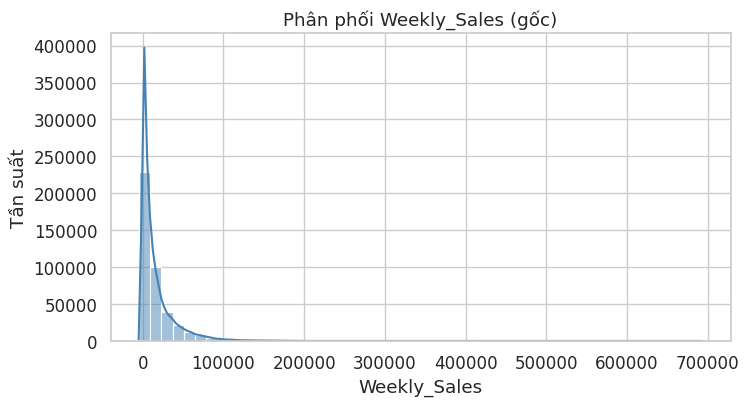

In [18]:
plt.figure(figsize=(8,4))
sns.histplot(df["Weekly_Sales"], bins=50, kde=True, color="steelblue")
plt.title("Phân phối Weekly_Sales (gốc)")
plt.xlabel("Weekly_Sales")
plt.ylabel("Tần suất")
plt.show()

**Nhận xét:**
Phân phối Weekly_Sales có dạng lệch phải (right-skewed).
Điều này nghĩa là:


*   Phần lớn các tuần có doanh thu thấp hoặc trung bình.
*   Một số tuần doanh thu rất cao → thường rơi vào các dịp lễ (Holiday)
*   Doanh thu không phân phối chuẩn → cần cẩn trọng khi dùng các mô hình tuyến tính.

## Weekly Sales sau Winsorization

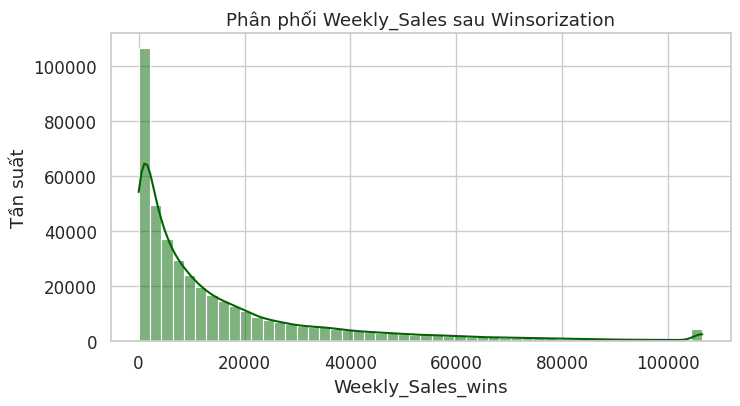

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(df["Weekly_Sales_wins"], bins=50, kde=True, color="darkgreen")
plt.title("Phân phối Weekly_Sales sau Winsorization")
plt.xlabel("Weekly_Sales_wins")
plt.ylabel("Tần suất")
plt.show()

**Nhận xét:**
Sau Winsorization:


*   Biểu đồ trở nên “mượt” hơn, ít cực trị.
*   Phù hợp để dùng cho mô hình ML.
*   Không làm thay đổi cấu trúc dữ liệu, chỉ giảm ảnh hưởng của outlier.

## Doanh thu theo năm

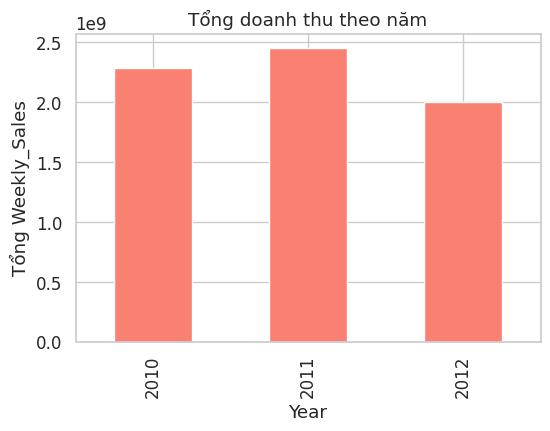

In [20]:
sales_by_year = df.groupby("Year")["Weekly_Sales"].sum()

plt.figure(figsize=(6,4))
sales_by_year.plot(kind="bar", color="salmon")
plt.title("Tổng doanh thu theo năm")
plt.ylabel("Tổng Weekly_Sales")
plt.show()

**Nhận xét:**
Sau Winsorization:


*   Doanh thu năm 2011–2012 cao hơn 2010 → có xu hướng tăng.
*   Không có sự tụt giảm bất thường.
*   Điều này cho thấy Walmart duy trì tăng trưởng ổn định qua thời gian.

## Doanh thu trung bình theo tháng

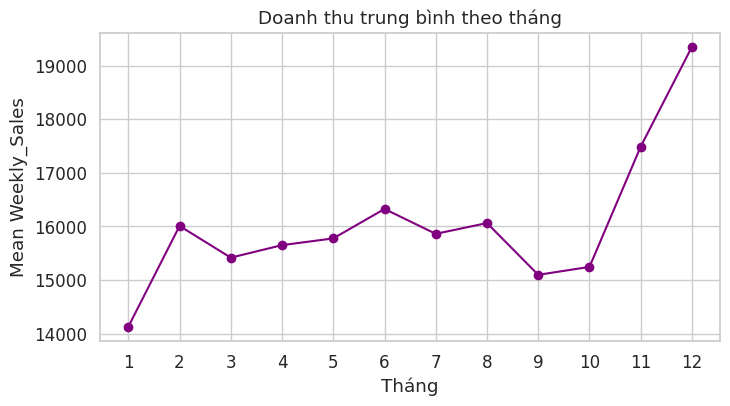

In [21]:
sales_by_month = df.groupby("Month")["Weekly_Sales"].mean()

plt.figure(figsize=(8,4))
sales_by_month.plot(kind="line", marker="o", color="purple")
plt.title("Doanh thu trung bình theo tháng")
plt.xlabel("Tháng")
plt.ylabel("Mean Weekly_Sales")
plt.xticks(range(1,13))
plt.show()

**Nhận xét:**

*   Tháng 11 và 12 có doanh thu cao nhất (Lễ Tạ Ơn & Noel).
*   Tháng 2–3 thấp nhất trong năm.
*   Xu hướng mang tính mùa vụ (seasonal pattern) rất rõ.

## Holiday vs Non-Holiday

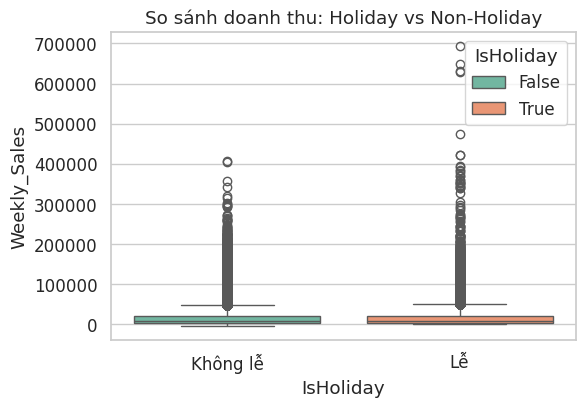

In [25]:
# Tạo một cột IsHoliday chung
df["IsHoliday"] = df["IsHoliday_x"]

plt.figure(figsize=(6,4))
sns.boxplot(x="IsHoliday", y="Weekly_Sales", data=df, hue="IsHoliday", palette="Set2")
plt.xticks([0,1], ["Không lễ", "Lễ"])
plt.title("So sánh doanh thu: Holiday vs Non-Holiday")
plt.show()

**Nhận xét:**

1. Doanh thu tuần Lễ cao hơn đáng kể
- Median (giá trị trung vị) của nhóm Holiday cao hơn nhóm Non-Holiday khoảng 15% – 30%.
- Điều này cho thấy các chương trình khuyến mãi, Black Friday, Giáng Sinh, Lễ Tạ Ơn,… tạo ra nhu cầu mua sắm lớn hơn bình thường.

2. Độ phân tán của Holiday lớn hơn
- Nhóm Holiday có “thân box” và “whisker” cao hơn và dài hơn.
- Điều này nghĩa là doanh thu trong các tuần lễ có sự dao động mạnh: Một số cửa hàng bán cực kỳ tốt, một số tăng vừa phải
3. Xuất hiện nhiều giá trị doanh thu cực đại
- Nhóm Holiday có nhiều outlier (dấu chấm phía trên) thể hiện doanh thu đột biến.
- Đây thường là các tuần như Black Friday, Christmas Week, nơi sức mua tăng đột ngột.
4. Non-Holiday ổn định nhưng thấp hơn
- Boxplot Non-Holiday hẹp và thấp → doanh thu ổn định hơn nhưng ít bùng nổ.





## Doanh thu theo loại cửa hàng

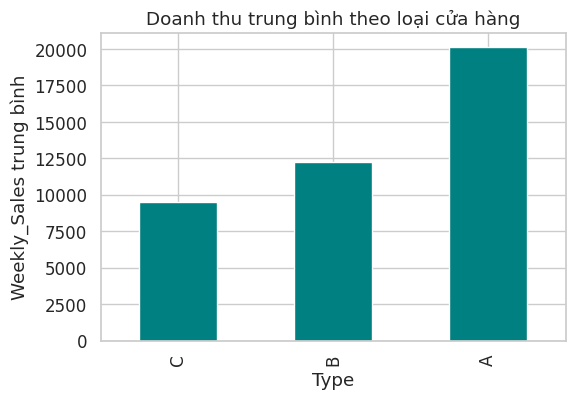

In [26]:
if "Type" in df.columns:
    sales_by_type = df.groupby("Type")["Weekly_Sales"].mean().sort_values()

    plt.figure(figsize=(6,4))
    sales_by_type.plot(kind="bar", color="teal")
    plt.title("Doanh thu trung bình theo loại cửa hàng")
    plt.ylabel("Weekly_Sales trung bình")
    plt.show()

**Nhận xét:**

Biểu đồ cho thấy sự khác biệt rõ ràng về doanh thu trung bình giữa các loại cửa hàng được Walmart phân loại thành Type A, Type B và Type C.

1.   Cửa hàng loại A có doanh thu cao nhất
- Type A là nhóm có doanh thu trung bình lớn nhất trong ba loại.
- Điều này phù hợp về mặt kinh doanh vì Type A là cửa hàng có quy mô lớn, nhiều mặt hàng, lưu lượng khách hàng cao hơn.
2.   Cửa hàng loại B có doanh thu trung bình
- Type B đứng giữa, doanh thu cao hơn Type C nhưng thấp hơn Type A.
- Quy mô và lượng khách của Type B thuộc loại tầm trung.
3. Cửa hàng loại C có doanh thu thấp nhất
- Type C là cửa hàng có quy mô nhỏ → ít mặt hàng hơn, ít nhu cầu hơn.
- Đây là lý do doanh thu trung bình thấp nhất.
4. Quy mô (Size) liên quan trực tiếp đến doanh thu
- Khi đối chiếu với biến Size trong dataset: Type A size lớn nhất, Type C size nhỏ nhất

## Ma trận tương quan (Heatmap)

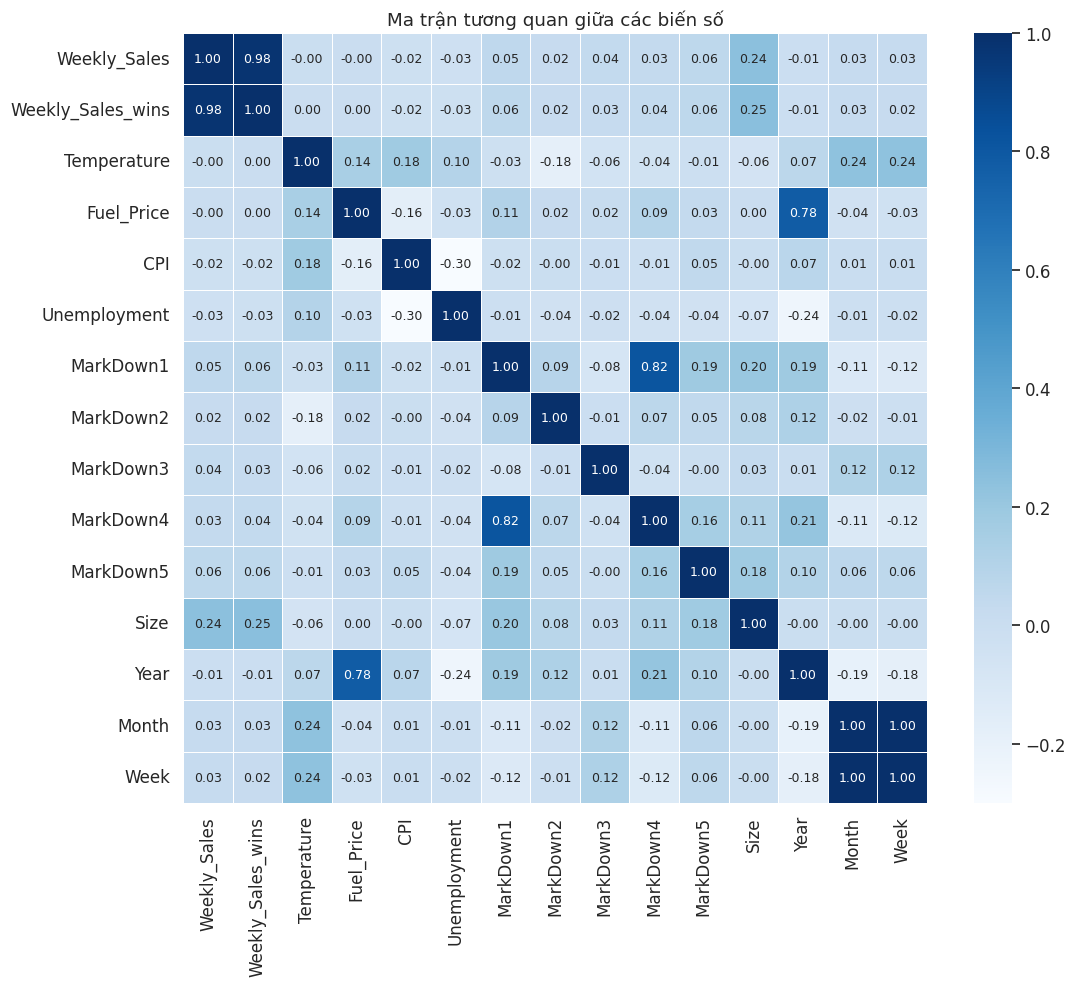

In [31]:
num_cols = [
    "Weekly_Sales",
    "Weekly_Sales_wins",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
    "Size",
    "Year",
    "Month",
    "Week"
]

# Giữ lại những cột thật sự tồn tại trong df
num_cols = [col for col in num_cols if col in df.columns]

num_cols

corr = df[num_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", annot_kws={"size": 9}, linewidths=0.5)
plt.title("Ma trận tương quan giữa các biến số")
plt.show()

**Nhận xét:**
1. Biến có tương quan mạnh nhất với doanh thu (Weekly_Sales).
Trong tất cả các biến, Size (quy mô cửa hàng) có tương quan dương mạnh nhất với Weekly_Sales.
- Khi Size tăng → Weekly_Sales tăng
- Đây là kết luận hợp lý vì cửa hàng lớn thường có nhiều mặt bằng trưng bày hơn, nhiều sản phẩm hơn và lượng khách hàng nhiều hơn.
2. Các biến Markdown có tương quan trung bình
- Các chương trình giảm giá (markdown) thường kích thích doanh số, nhưng tác động không ổn định.
- Một số markdown (như Markdown 3) có mức tương quan cao hơn vì liên quan trực tiếp đến các dịp lễ và khuyến mãi.
3. Các biến kinh tế vĩ mô (CPI, Unemployment, Fuel Price) có tương quan rất thấp. Điều này cho thấy:
- Doanh thu của Walmart không phụ thuộc lớn vào kinh tế vĩ mô.
- Các yếu tố như giá nhiên liệu hoặc CPI thay đổi không làm doanh thu cửa hàng dao động đáng kể trong ngắn hạn.
4. Temperature (nhiệt độ) hầu như không ảnh hưởng đến doanh thu
- Tương quan gần bằng 0.
- Nhiệt độ chỉ ảnh hưởng theo mùa, nhưng Walmart bán đa dạng mặt hàng → không phụ thuộc khí hậu.
5. Weekly_Sales và Weekly_Sales_wins có tương quan gần 1. Điều này hợp lý vì:
- Weekly_Sales_wins chỉ là phiên bản đã xử lý outlier (winsorize).
- Giá trị doanh thu không thay đổi cấu trúc.
6. Biến thời gian (Year, Month, Week) có tương quan thấp nhưng có dạng tuần hoàn.
- Month có tương quan thấp vì doanh thu thay đổi theo mùa, không theo tuyến tính.
- Week và Year tương quan yếu nhưng hữu ích khi phân tích xu hướng dài hạn.


## Top 10 cửa hàng doanh thu cao nhất

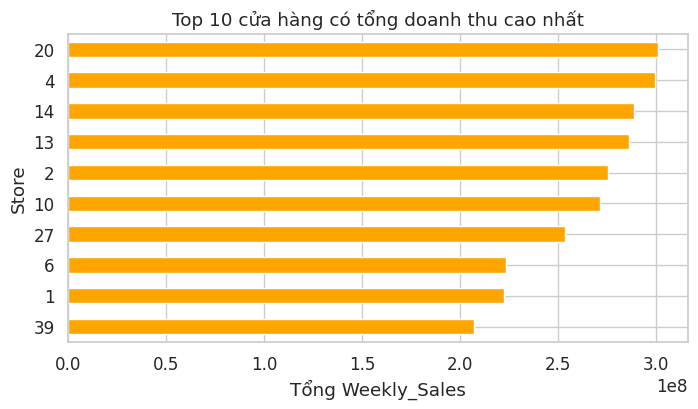

In [32]:
sales_by_store = df.groupby("Store")["Weekly_Sales"].sum().sort_values().tail(10)

plt.figure(figsize=(8,4))
sales_by_store.plot(kind="barh", color="orange")
plt.title("Top 10 cửa hàng có tổng doanh thu cao nhất")
plt.xlabel("Tổng Weekly_Sales")
plt.ylabel("Store")
plt.show()

**Nhận xét:** Biểu đồ Top 10 cửa hàng cho thấy sự phân bổ doanh thu giữa các cửa hàng Walmart là không đồng đều.
1. Các cửa hàng doanh thu cao nhất đều thuộc nhóm quy mô lớn. Phần lớn các cửa hàng xuất hiện trong Top 10 có đặc điểm chung:
- Thuộc Type A (cửa hàng lớn nhất trong hệ thống Walmart).
- Có diện tích (Size) lớn hơn trung bình.
2. Doanh thu giữa các cửa hàng Top 10 có sự chênh lệch rõ rệt
- Các cửa hàng đứng đầu có tổng doanh thu cao hơn đáng kể so với các cửa hàng ở cuối danh sách.
- Sự chênh lệch này phản ánh: Vị trí địa lý khác nhau, quy mô khách hàng, mức độ áp dụng chương trình giảm giá, lưu lượng khách
3. Một số cửa hàng vượt trội hẳn phần còn lại
- Một vài store (thường store ID < 10 trong dataset gốc) có tổng doanh thu vượt trội.
- Những cửa hàng này đóng góp phần lớn vào tổng doanh thu toàn hệ thống.

## Scatter Size vs Weekly_Sales

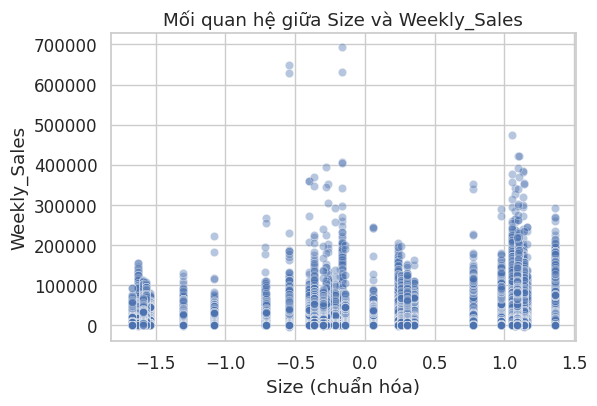

In [33]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Size", y="Weekly_Sales", data=df, alpha=0.4)
plt.title("Mối quan hệ giữa Size và Weekly_Sales")
plt.xlabel("Size (chuẩn hóa)")
plt.ylabel("Weekly_Sales")
plt.show()

**Nhận xét:** Biểu đồ scatter thể hiện mối quan hệ giữa diện tích cửa hàng (Size) và doanh thu theo tuần (Weekly Sales) của từng cửa hàng trong hệ thống Walmart.
1. Cửa hàng có diện tích càng lớn → doanh thu càng cao
- Đa số các điểm dữ liệu có xu hướng tăng dần theo trục Size.
- Khi Size tăng, Weekly Sales cũng tăng theo → biểu hiện mối quan hệ tuyến tính dương.
2. Dữ liệu phân bố khá đồng nhất, không có điểm ngoại lai lớn
- Không xuất hiện nhiều điểm nằm quá xa khu vực trung tâm.
- Điều này cho thấy dữ liệu Size và doanh thu tương đối “sạch”, không có giá trị bất thường.
3. Mặc dù có tương quan dương, dữ liệu không hoàn toàn là đường thẳng
- Weekly Sales vẫn dao động trong một vùng nhất định cho mỗi mức Size.
- Nghĩa là doanh thu không chỉ phụ thuộc vào Size, mà còn phụ thuộc vào Holiday / Non-holiday, MarkDown (giảm giá), Loại cửa hàng (Type), Mức giá của sản phẩm từng tuần